C:\Users\shifa\AppData\Local\Temp\ipykernel_54548\3685406759.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = rgi.geometry.centroid


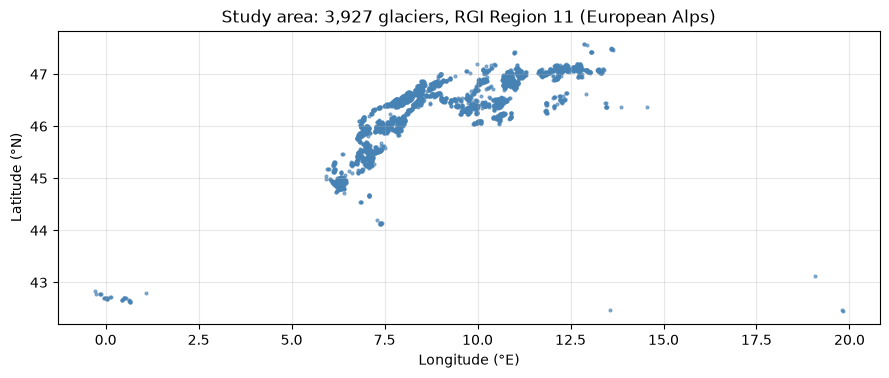

In [9]:
#figure 1: study area map
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "savefig.facecolor":"white","text.color":"black",
                     "axes.labelcolor":"black","xtick.color":"black","ytick.color":"black"})

rgi = gpd.read_file(r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\RGI\nsidc0770_11.rgi60.CentralEurope\11_rgi60_CentralEurope.shp")

# use glacier centroids as points (polygons are tiny at this scale)
cent = rgi.geometry.centroid

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(cent.x, cent.y, s=4, color="steelblue", alpha=0.6)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(f"Study area: {len(rgi):,} glaciers, RGI Region 11 (European Alps)")
ax.grid(alpha=0.3)
ax.set_aspect(1.4)   # roughly correct aspect for Alpine latitudes
plt.tight_layout()
plt.savefig("../Figures/fig1_study_area.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\shifa\AppData\Local\Temp\ipykernel_54548\461849640.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = rgi.geometry.centroid


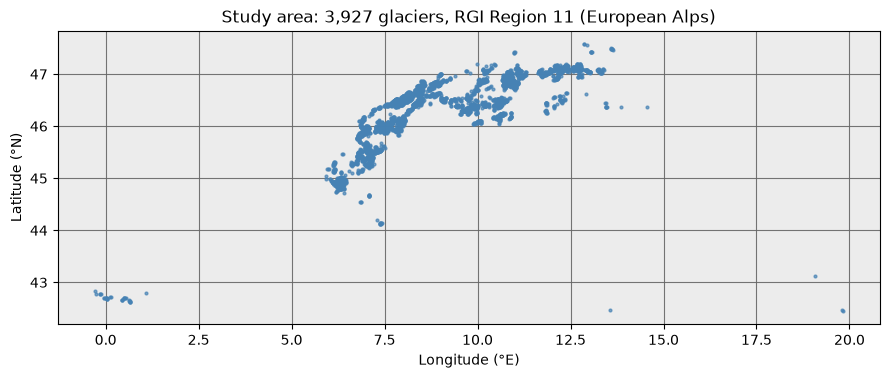

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor":"white","savefig.facecolor":"white",
                     "text.color":"black","axes.labelcolor":"black",
                     "xtick.color":"black","ytick.color":"black"})

rgi = gpd.read_file(r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\RGI\nsidc0770_11.rgi60.CentralEurope\11_rgi60_CentralEurope.shp")

cent = rgi.geometry.centroid

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_facecolor("#ececec")          # light grey plot background

ax.scatter(cent.x, cent.y, s=4, color="steelblue", alpha=0.7, zorder=3)

# darker, clearly visible gridlines
ax.grid(True, color="#666666", linewidth=0.8, alpha=0.9, zorder=1)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(f"Study area: {len(rgi):,} glaciers, RGI Region 11 (European Alps)")
ax.set_aspect(1.4)
plt.tight_layout()
plt.savefig("../Figures/fig1_study_area3.png", dpi=200, bbox_inches="tight")
plt.show()

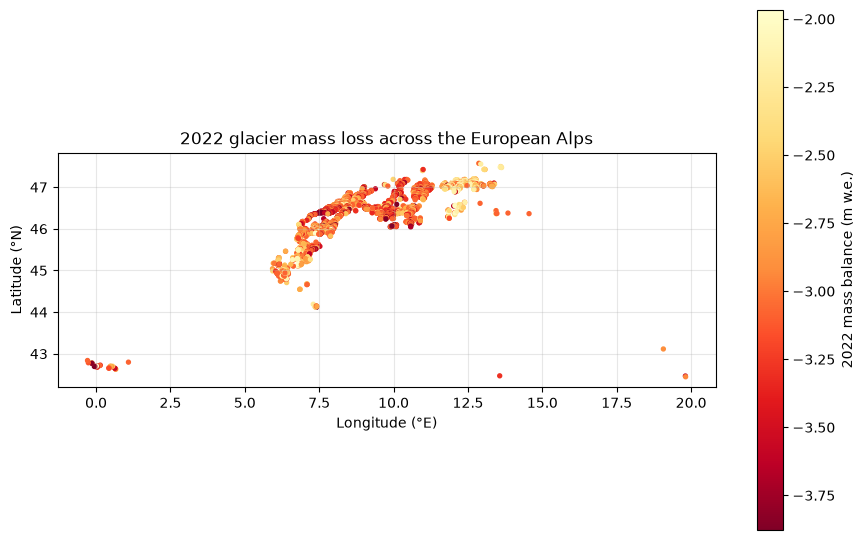

In [10]:
# Figure 2: Region 11 coloured map indicating mass loss
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "savefig.facecolor":"white","text.color":"black",
                     "axes.labelcolor":"black","xtick.color":"black","ytick.color":"black"})

df = pd.read_csv("../Data/Processed/stage4_with_2022.csv")

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(df["CenLon"], df["CenLat"], c=df["mb_2022"],
                cmap="YlOrRd_r", s=8, vmin=df["mb_2022"].quantile(0.02),
                vmax=df["mb_2022"].quantile(0.98))
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("2022 mass balance (m w.e.)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title("2022 glacier mass loss across the European Alps")
ax.grid(alpha=0.3)
ax.set_aspect(1.4)
plt.tight_layout()
plt.savefig("../Figures/fig2_mb2022_map.png", dpi=200, bbox_inches="tight")
plt.show()

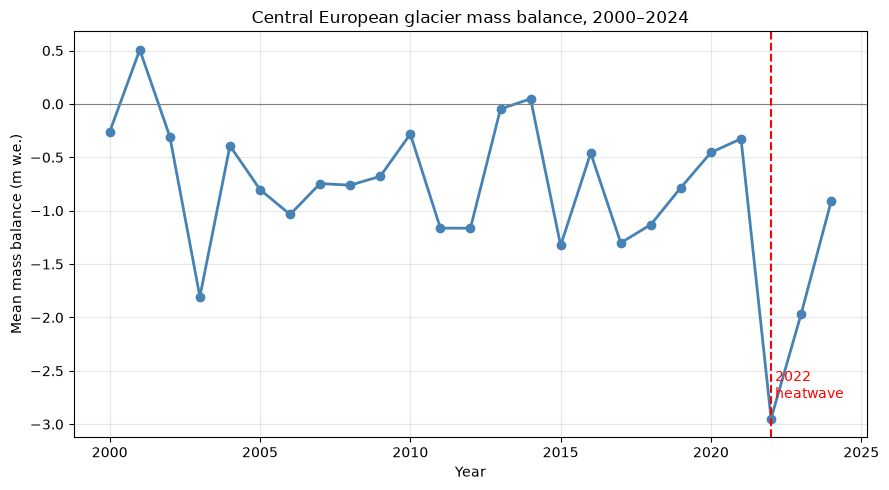

2022 value: -2.95 | 2000-2019 mean: -0.69


In [11]:
# Figure 3: Regional Time series 2000-2024

import os, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "savefig.facecolor":"white","text.color":"black",
                     "axes.labelcolor":"black","xtick.color":"black","ytick.color":"black"})

folder = r"C:\DATA\Dissertation\Glacier_Mass\Glacier_Mass_Balance\Glacier_Mass_Balance\Data\Raw\WGMS\wgms-amce-2025-02b\wgms-amce-2025-02b\individual-glacier"
d = pd.read_csv(os.path.join(folder, "CEU_gla_MEAN-CAL-mass-change-series_obs_unobs.csv"))

years = list(range(2000, 2025))
regional = d[[str(y) for y in years]].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(years, regional.values, marker="o", color="steelblue", linewidth=2)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(2022, color="red", linestyle="--", linewidth=1.5)
ax.text(2022, regional.min()*0.95, " 2022\n heatwave", color="red", fontsize=10, va="bottom")
ax.set_xlabel("Year")
ax.set_ylabel("Mean mass balance (m w.e.)")
ax.set_title("Central European glacier mass balance, 2000–2024")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Figures/fig3_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

print("2022 value:", round(regional["2022"], 2),
      "| 2000-2019 mean:", round(regional[[str(y) for y in range(2000,2020)]].mean(), 2))

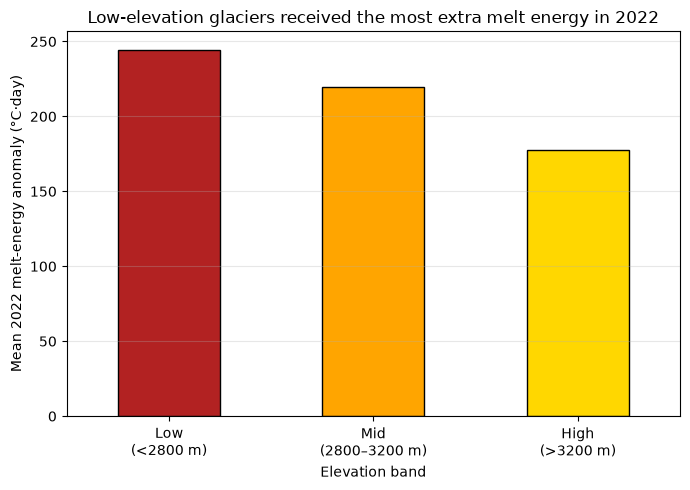

In [12]:
# Figure 4: 2022 anomaly
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "savefig.facecolor":"white","text.color":"black",
                     "axes.labelcolor":"black","xtick.color":"black","ytick.color":"black"})

df = pd.read_csv("../Data/Processed/stage4_with_2022.csv")

df["elev_band"] = pd.cut(df["Zmed"], [0, 2800, 3200, 6000],
                         labels=["Low\n(<2800 m)", "Mid\n(2800–3200 m)", "High\n(>3200 m)"])
means = df.groupby("elev_band", observed=True)["apdd_anom_2022"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
means.plot.bar(ax=ax, color=["firebrick","orange","gold"], edgecolor="black")
ax.set_ylabel("Mean 2022 melt-energy anomaly (°C·day)")
ax.set_xlabel("Elevation band")
ax.set_title("Low-elevation glaciers received the most extra melt energy in 2022")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../Figures/fig4_elevation_bands.png", dpi=200, bbox_inches="tight")
plt.show()